#Part 4: Data Visualization & Machine Learning

In [15]:
from google.colab import files
uploaded = files.upload()

Saving students.csv to students.csv


#Task 1 - Data Exploration with Pandas

In [24]:
import pandas as pd

df = pd.read_csv("students.csv") # load dataset

# print first 5 rows
print("First 5 rows:")
print(df.head())

# print shape and data types
print("\nShape (rows, columns):", df.shape)
print("\nData types:")
print(df.dtypes)

# summary statistics for numeric columns
print("\nSummary statistics:")
print(df.describe())

# count of students who passed and failed
print("\nPass and fail count:")
print(df['passed'].value_counts())

# average score per subject for pass and fail students
subject_cols = ['math', 'science', 'english', 'history', 'pe']
pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\nAverage scores for passed students:")
print(pass_avg)

print("\nAverage scores for failed students:")
print(fail_avg)

# student with highest overall average
df['avg_total'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['avg_total'].idxmax()]

print("\nTop student:")
print(top_student['name'], "with average:", top_student['avg_total'])

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  study_hours_per_day  passed
0    Alice    88       92       76       80  95              92                  4.5       1
1      Bob    42       55       48       50  60              65                  1.2       0
2  Charlie    75       70       80       68  88              85                  3.0       1
3    Diana    95       98       91       89  97              98                  6.0       1
4      Eve    38       42       50       45  55              58                  0.8       0

Shape (rows, columns): (15, 9)

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary statistics:
            math    science    english    history         pe  attenda

#Task 2 - Data Visualization with Matplotlib

In [57]:
import matplotlib.pyplot as plt

# add avg_score column
df['avg_score'] = df[subject_cols].mean(axis=1)

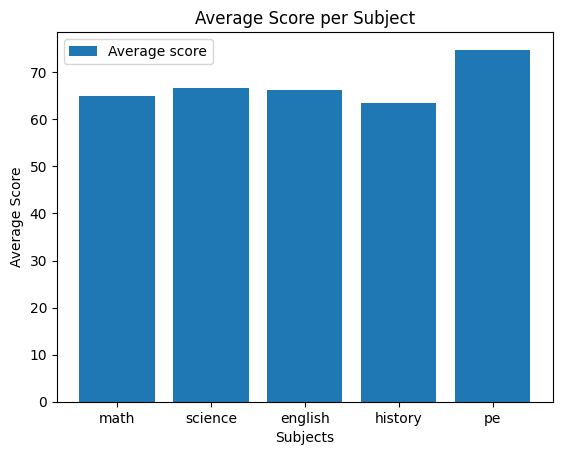

In [28]:
# Bar chart

# average for each subject across all students
subject_means = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, subject_means, label = "Average score")

# title
plt.title("Average Score per Subject")

# labels
plt.xlabel("Subjects")
plt.ylabel("Average Score")

# legend
plt.legend()

plt.savefig("plot1_bar.png")
plt.show()

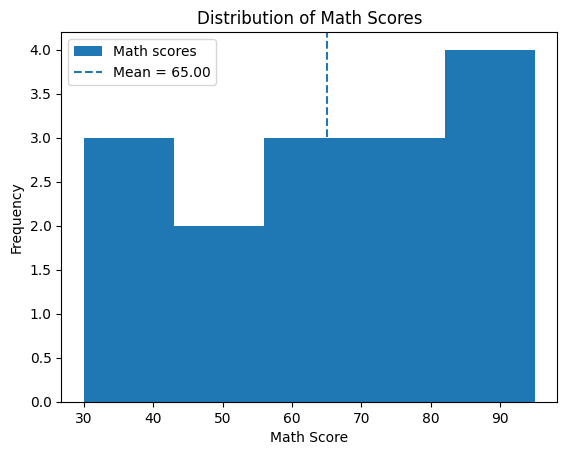

In [35]:
# Histogram distribution of math scores with 5 bins
plt.figure()

# histogram plotting
plt.hist(df['math'], bins=5, label = "Math scores")

# add a vertical dashed line at the mean math score and label it
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed',label=f"Mean = {mean_math:.2f}")

# title
plt.title("Distribution of Math Scores")

#labels
plt.xlabel("Math Score")
plt.ylabel("Frequency")

# legend
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

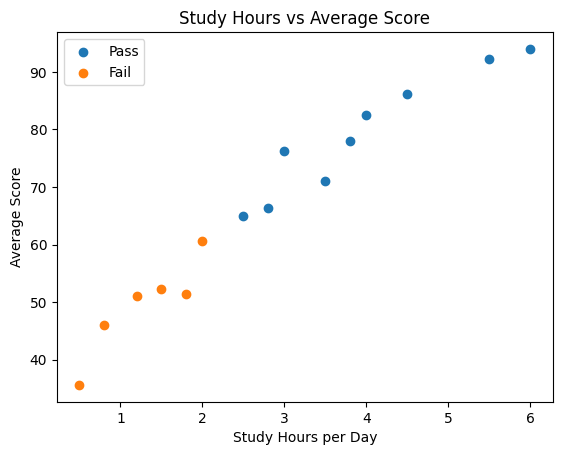

In [36]:
# Scatter plot - study_hours_per_day (x-axis) vs avg_score (y-axis)
plt.figure()

# separate pass/fail groups
pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

# separate plots to colour each point differently (pass and fail)
plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_33167/617669399.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


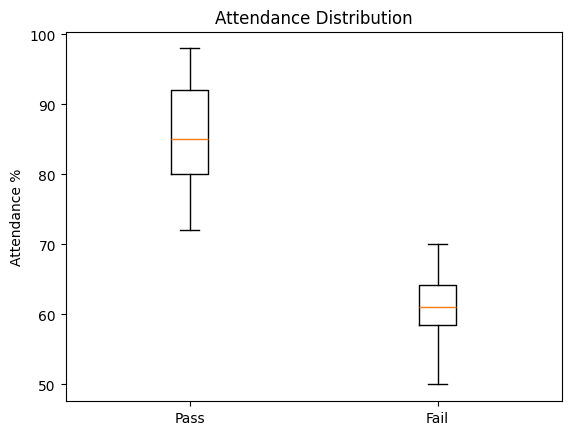

In [34]:
# Box plot - distribution of attendance_pct for passing students vs failing students
plt.figure()

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

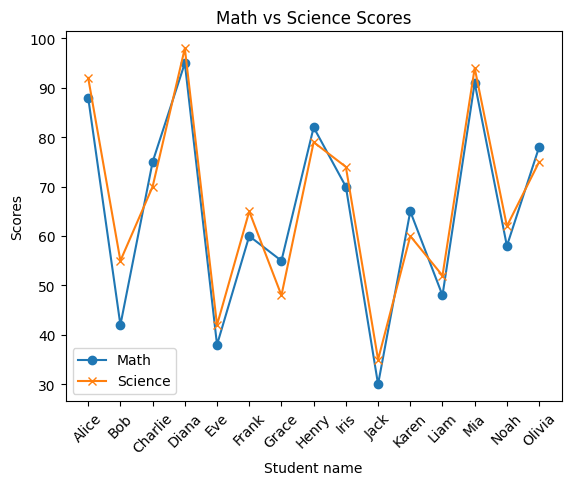

In [37]:
# Line Plot - math score and science score for every student

plt.figure()

# plot math and science scores of students
plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='x', label="Science")

plt.xticks(rotation=45)

plt.title("Math vs Science Scores")
plt.xlabel("Student name")
plt.ylabel("Scores")

plt.legend()

plt.savefig("plot5_line.png")
plt.show()

#Task 3 - Data Visualization with Seaborn

In [58]:
import seaborn as sns

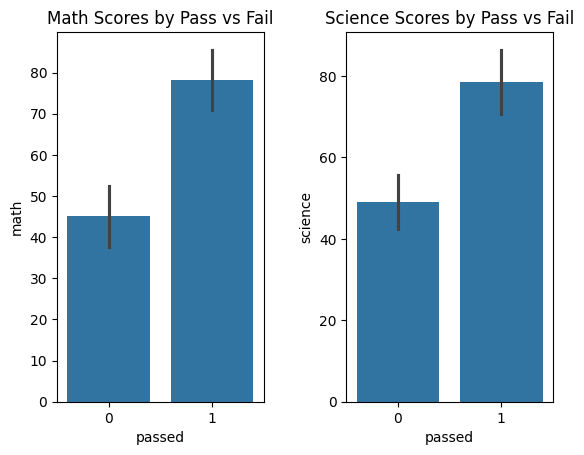

In [55]:
import matplotlib.pyplot as plt

# Seaborn bar plot - average math score and average science score
fig, (ax1, ax2) = plt.subplots(1, 2)

# math barplot
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math Scores by Pass vs Fail")

# science barplot
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Science Scores by Pass vs Fail")

plt.subplots_adjust(wspace=0.4)
plt.savefig("plot6_seaborn_bar.png")
plt.show()

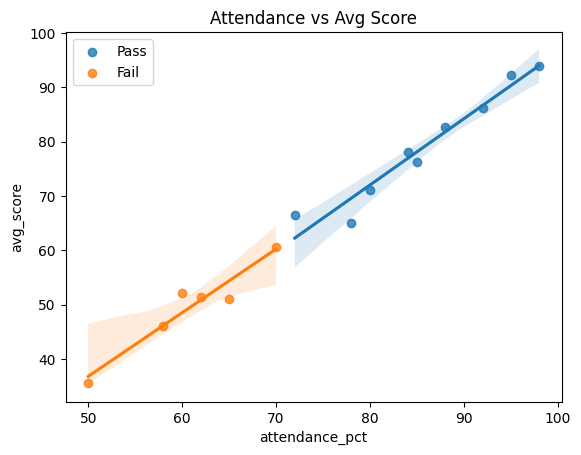

In [56]:
# Seaborn scatter plot of attendance_pct (x-axis) vs avg_score (y-axis)

plt.figure()

# pass group
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', label='Pass')

# fail group
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', label='Fail')

plt.legend()
plt.title("Attendance vs Avg Score")

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [ ]:
# Seaborn is easier for statistical plots like barplots and regression lines.
# Seaborn automatically calculates aggregates and trends but offers limited control.
# Matplotlib requires more work for tasks like setting legend, labels.
# Matplotlib gives more control but requires more manual coding.

#Task 4 - Machine Learning with scikit-learn

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [48]:
# Step 1 - prepare data:

# features
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]

# target
y = df['passed']

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
# Step 2 - train model:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# training accuracy
print("Training Accuracy:", model.score(X_train_scaled, y_train))

Training Accuracy: 1.0


In [52]:
# Step 3 - evaluate model:

# predict on test set
y_pred = model.predict(X_test_scaled)

print("Test Accuracy:", model.score(X_test_scaled, y_test),"\n")

# print results
for idx, pred in zip(X_test.index, y_pred):
    name = df.loc[idx, 'name']
    actual = df.loc[idx, 'passed']

    result = "✅ correct" if pred == actual else "❌ wrong"

    print(f"{name}: Actual={actual}, Predicted={pred} {result}\n")

Test Accuracy: 1.0 

Jack: Actual=0, Predicted=0 ✅ correct

Liam: Actual=0, Predicted=0 ✅ correct

Alice: Actual=1, Predicted=1 ✅ correct




Feature Importance:
english: 0.8125127982724648
attendance_pct: 0.521876340433209
study_hours_per_day: 0.4844326627100155
pe: 0.47497406284967797
math: 0.43794393086873595
science: 0.3230097624690249
history: 0.26292892629062437


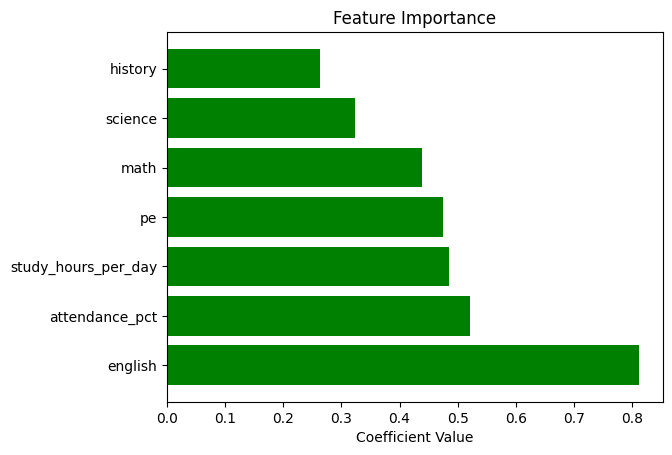

In [53]:
# Step 4 - feature importance:

import matplotlib.pyplot as plt

# extract model coefficients
coeffs = model.coef_[0]
features = X.columns

# pair each coefficient with its feature name and print them, sorted by absolute value (largest first)
feature_importance = sorted(zip(features, coeffs), key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:")
for f, c in feature_importance:
    print(f"{f}: {c}")

# horizontal bar chart showing all feature coefficients
names = [f for f, _ in feature_importance]
values = [c for _, c in feature_importance]

colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()
plt.barh(names, values, color=colors)

plt.title("Feature Importance")
plt.xlabel("Coefficient Value")

plt.savefig("feature_importance.png")
plt.show()

In [54]:
# Step 5 - predict for new student:

# new student data
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# scale
new_scaled = scaler.transform(new_student)

# prediction
prediction = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("\nPrediction:", "Pass" if prediction[0] == 1 else "Fail")
print("Probability:", prob)


Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
